In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 

from scipy.ndimage import gaussian_filter
from matplotlib.picolors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from matplotlib import colors
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
import importlib


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/rns/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/rns/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/rns/.local/lib/python3.10/site-packages/ipy

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
data = np.loadtxt('rednoise_fix_injections.txt')
print(f'Number of pointings: {len(np.unique(data[:, 0:2], axis=0))}')
#print(f'Number of days: {len(np.unique(data[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data[data[:, -1] > 0.])/len(data)):.2f}%')
print(f'Number of injections: {len(data)}')
RA = data[:, 0]
Dec = data[:, 1]
f = data[:, 4]
DM = data[:, 5]
S = data[:, 6]
TPA_idx = data[:, 3].astype('int')
fwhm = data[:, 7]

f_idx = 4 
DM_idx = 5
S_idx = 6
FWHM_idx = 7

Number of pointings: 15429
Total fraction of recovered injections: 38.25%
Number of injections: 154114


In [ ]:
fglob_mask = (data[:, f_idx] > 0.1) & (data[:, f_idx] < 250.)
DMglob_mask = (data[:, DM_idx] > 1.) & (data[:, DM_idx] < 600.)
Sglob_mask = data[:, S_idx] > 0.1
glob_mask = fglob_mask & DMglob_mask & Sglob_mask

In [ ]:
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1000)
S_bins = np.logspace(np.log10(0.05), np.log10(max(S)), 1000)

f_dev = 100
S_dev = 100

In [ ]:
day_mask = data[:, 2] == 1.
month_mask = (data[:, 2] == 30) | (data[:, 2] == 31)

_, _, s_f_trans_day = au.get_sensitivity(
   data[DMglob_mask & day_mask],
   *(6, 4, S_bins, f_bins, S_dev, f_dev),
   stype = '2d',
)

_, _, s_f_trans_month = au.get_sensitivity(
   data[DMglob_mask & month_mask],
   *(6, 4, S_bins, f_bins, S_dev, f_dev),
   stype = '2d',
)

/home/rns/work/Transmissivity/scripts/analysis_utils.py:35: RuntimeWarning: invalid value encountered in true_divide
  arr_ret_p = arr_retrieved / arr_injected


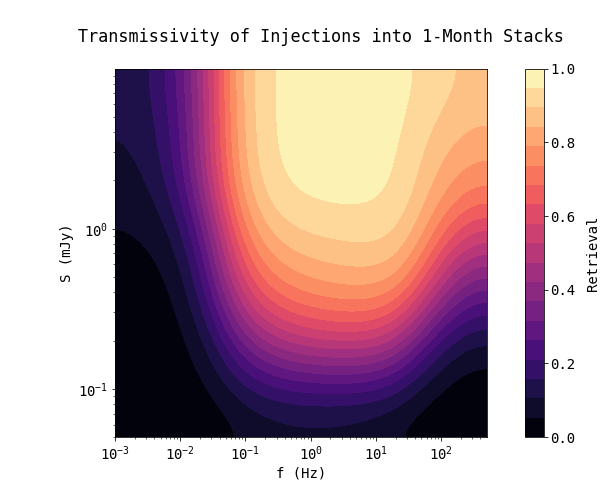

In [ ]:
levels = au.make_levels(s_f_trans_month, 
                        logspace = False,
                        diverging = False) 

fig, ax = plt.subplots(figsize=(8, 7))


cf = ax.contourf(f_bins[:-1], S_bins[:-1], 
                         s_f_trans_month, 
                         levels=levels,
                         cmap = 'magma')
ax.set_xscale('log')
ax.set_yscale('log')
    
ax.set_xlabel('f (Hz)')
ax.set_ylabel('S (mJy)')
ax.set_title('\n       Transmissivity of Injections into 1-Month Stacks   \n')
ax.set_facecolor('k')

cbar = fig.colorbar(cf, ax=ax, location='right', pad=0.08)
cbar.set_label('Retrieval', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])

plt.tight_layout()

In [ ]:
importlib.reload(au)

<module 'scripts.analysis_utils' from '/home/rns/work/Transmissivity/scripts/analysis_utils.py'>

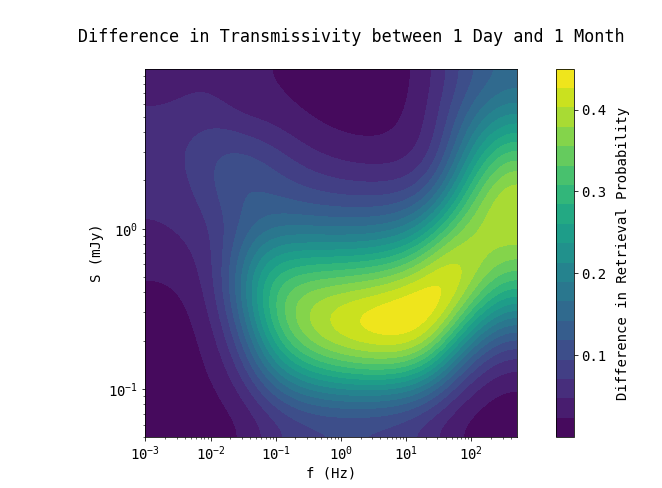

In [ ]:
s_f_diff = s_f_trans_month - s_f_trans_day

levels = au.make_levels(s_f_diff, 
                        logspace = False,
                        diverging = False,
                        custom_bounds = [0, 0.45]) 

fig, ax = plt.subplots(figsize=(8, 7))


cf = ax.contourf(f_bins[:-1], S_bins[:-1], 
                         s_f_diff, 
                         levels=levels,
                         cmap = 'viridis')
ax.set_xscale('log')
ax.set_yscale('log')
    
ax.set_xlabel('f (Hz)')
ax.set_ylabel('S (mJy)')
ax.set_title('\n       Difference in Transmissivity between 1 Day and 1 Month   \n')
ax.set_facecolor('k')

cbar = fig.colorbar(cf, ax=ax, location='right', pad=0.08)
cbar.set_label('Difference in Retrieval Probability', labelpad=10)
cbar.set_ticks([0.1, 0.2, 0.3, 0.4])

plt.tight_layout()

In [ ]:
with open('discoveries_20260622.txt', 'r') as f: #stupid pandas wont import

    lines = f.readlines()

print(lines)

NameError: name 'pd' is not defined